# Projeto Avaliativo – Análise de Dados com Python

## Fase 3 – Camada Gold: Análise de Dados

## Introdução



Este notebook apresenta a etapa de análise de dados (Camada Gold) do pipeline desenvolvido para o conjunto de dados Viagens a Serviço, disponibilizado pelo Portal da Transparência do Governo Federal.

Após a extração dos dados e sua transformação nas camadas Raw e Silver, são realizadas consultas analíticas para responder às perguntas de negócio propostas no projeto. As análises utilizam consultas SQL, tabelas e gráficos para transformar os dados tratados em informações que apoiam a compreensão dos gastos com viagens a serviço.

Além disso, é criada uma camada Gold com dados agregados, utilizando operações de JOIN e GROUP BY, permitindo a geração de indicadores voltados à tomada de decisão.

## Configuração do Ambiente

Nesta etapa são importadas as bibliotecas utilizadas nas análises e estabelecida a conexão com o banco de dados criado nas etapas anteriores do pipeline.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import banco

In [ ]:
conexao = banco.conectar()

## Visão Geral da Base de Dados

Antes de responder às perguntas de negócio, são apresentados alguns indicadores gerais da base utilizada nas análises, como a quantidade de registros e o período coberto pelos dados. Essas informações auxiliam na contextualização dos resultados apresentados nas seções seguintes.

### Quantidade de registros

In [ ]:
consulta_registros = """
SELECT 'silver_viagem' AS tabela, COUNT(*) AS total_registros
FROM silver_viagem

UNION ALL

SELECT 'silver_pagamento', COUNT(*)
FROM silver_pagamento

UNION ALL

SELECT 'silver_passagem', COUNT(*)
FROM silver_passagem

UNION ALL

SELECT 'silver_trecho', COUNT(*)
FROM silver_trecho;
"""

df_registros = pd.read_sql(consulta_registros, conexao)

display(df_registros)

### Análise dos resultados

A camada Silver é composta por 341.860 viagens, 606.916 pagamentos, 167.260 passagens e 763.349 trechos. Esses volumes demonstram que a base possui dados suficientes para responder às perguntas de negócio propostas, servindo como fonte para a construção da camada Gold.

### Período dos dados

Nesta etapa é identificado o período coberto pelos registros de viagens presentes na base de dados. Essa informação permite contextualizar temporalmente as análises realizadas nas seções seguintes.

In [ ]:
consulta_periodo = """
SELECT
    MIN(data_inicio) AS primeira_data,
    MAX(data_fim) AS ultima_data
FROM silver_viagem;
"""

df_periodo = pd.read_sql(consulta_periodo, conexao)

display(df_periodo)

In [ ]:
consulta_periodo_inicio = """
SELECT
    MIN(data_inicio) AS primeira_inicio,
    MAX(data_inicio) AS ultimo_inicio
FROM silver_viagem;
"""

df_periodo_inicio = pd.read_sql(consulta_periodo_inicio, conexao)

display(df_periodo_inicio)

### Análise dos resultados

A análise do período demonstra que as viagens consideradas na base tiveram início entre 01/01/2025 e 30/06/2025, correspondendo ao intervalo de seis meses disponibilizado para o projeto. 

Observa-se também que a data final das viagens se estende até 05/04/2026, indicando a existência de registros iniciados no primeiro semestre de 2025 com encerramento posterior. Essa característica foi considerada para evitar interpretações incorretas sobre o período analisado.

## Pergunta 1 – Quais são os 5 órgãos com maior custo total?

Para identificar os órgãos com maior impacto financeiro, foi realizada uma agregação dos valores totais das viagens por órgão superior. A análise considera a soma do campo valor_total da camada Silver, permitindo identificar quais órgãos concentraram os maiores gastos no período analisado.

In [13]:
consulta_top5_orgaos = """
SELECT
    nome_orgao_superior AS orgao,
    SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
"""

df_top5_orgaos = pd.read_sql(consulta_top5_orgaos, conexao)

display(df_top5_orgaos)

C:\Users\Win10\AppData\Local\Temp\ipykernel_16628\2389686907.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top5_orgaos = pd.read_sql(consulta_top5_orgaos, conexao)


,orgao,custo_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08
1,Ministério da Defesa,1.560703e+08
2,Ministério da Educação,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07
4,Ministério da Previdência Social,4.041731e+07


### Visualização dos resultados

O gráfico abaixo apresenta os cinco órgãos com maior custo total em viagens, permitindo comparar a concentração dos gastos entre as instituições.

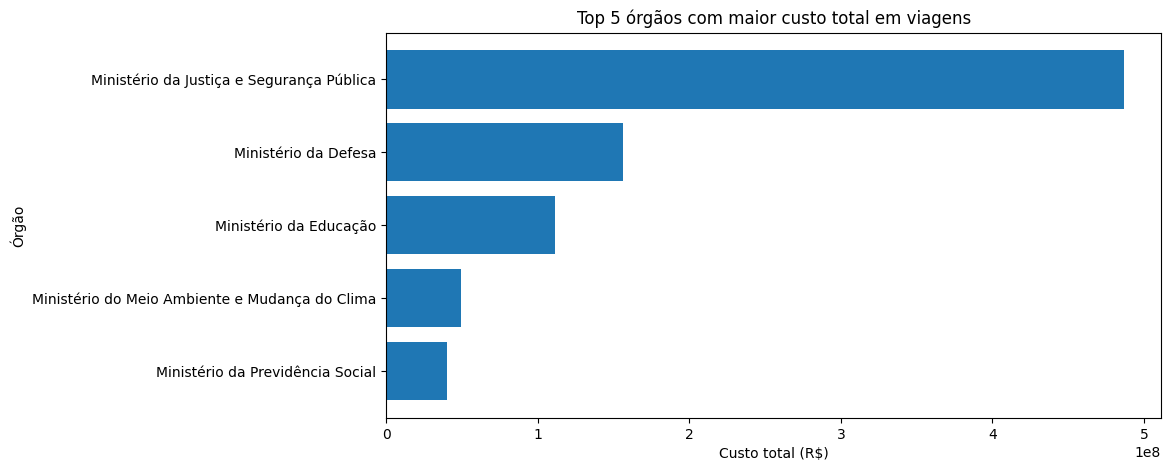

In [14]:
plt.figure(figsize=(10,5))

plt.barh(
    df_top5_orgaos["orgao"],
    df_top5_orgaos["custo_total"]
)

plt.xlabel("Custo total (R$)")
plt.ylabel("Órgão")
plt.title("Top 5 órgãos com maior custo total em viagens")

plt.gca().invert_yaxis()

plt.show()

### Conclusão da pergunta

A análise evidencia uma concentração significativa dos gastos em poucos órgãos, com destaque para o Ministério da Justiça e Segurança Pública, que apresentou o maior custo total no período analisado. Esse indicador permite direcionar análises mais aprofundadas sobre os fatores que influenciam os gastos de cada órgão.